In [185]:
import numpy as np
from pypkg.utils import *
from pypkg.propagator import *
from pypkg.transmittancefunc import *


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [407]:
def lsheet_phase(X: np.ndarray, f: float, xshift: float, lamb: float=0.532*um) -> np.ndarray:
    phase = 2*np.pi / lamb * (np.sqrt((X-xshift)**2 + f**2) - f)
    phase = np.exp(-1j*phase)
    return phase

def mlens_phase(X: np.ndarray, Y: np.ndarray, xshift: float, f: float, lamb: float=0.532*um) -> np.ndarray:
    phase = 2*np.pi / lamb * (np.sqrt((X-xshift)**2 + Y**2 + f**2) - f)
    phase = np.exp(-1j*phase)
    return phase

def tilt_lens(X: np.ndarray, angle: float, lamb: float=0.532*um):
    phase = 2*np.pi / lamb * X * np.tan(np.deg2rad(angle))
    phase = np.exp(1j*phase)
    return phase

In [440]:
m = 1
cm = 1e-2 * m
mm = 1e-3 * m
um = 1e-6 * m
nm = 1e-9 * m

M = 300
f = 10*mm
L = 1*mm
lamb = 532*nm

num_stack = 200
num_angle = 30
lsvolume = np.zeros((M, M, num_stack))
mlvolume = np.zeros((M, M, num_stack))
anglevolume = np.zeros((M, M, num_angle), dtype=np.complex128)

field = np.ones((M, M))

lsphase = lsheet_phase(X=X, f=f, xshift=0*mm)
lstilt = tilt(field, L, lamb, alpha=45, theta=0)
mlphase = mlens_phase(X=X, Y=Y, f=f, xshift=0*mm)
mltilt = tilt(field, L, lamb, alpha=-0, theta=0)

_, _, X, Y = spatial_grid(L=L, M=M)

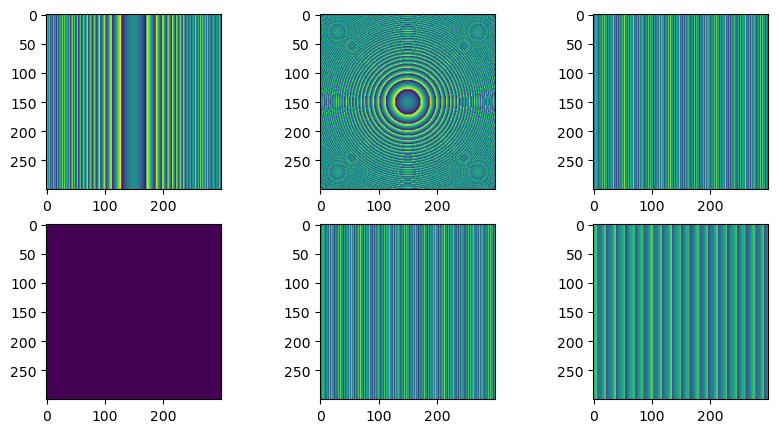

In [441]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))
ax = ax.ravel()
ax[0].imshow(np.angle(lsphase))
ax[1].imshow(np.angle(mlphase))
ax[2].imshow(np.angle(lstilt))
ax[3].imshow(np.angle(mltilt))
ax[4].imshow(np.angle(tilt_lens(X=X, angle=45)))
ax[5].imshow(np.angle(lstilt * tilt_lens(X=X, angle=45)))



In [ ]:
for idx, dist in enumerate(np.linspace(0, 2*f, num_stack)):
    lsimg = RSpropTF(field * lsphase * tilt_lens(X=X, angle=-45), L=L, wavelength=lamb, z=dist)
    # mlimg = RSpropTF(field * mlphase, L=L, wavelength=lamb, z=dist)
    lsvolume[:, :, idx] = lsimg
    # mlvolume[:, :, idx] = mlimg

In [445]:
for idx, dist in enumerate(np.linspace(0, 2*f, num_stack)):
    for jdx, angle in enumerate(np.linspace(-30, 30, 100)):
        mlangle_img = RSpropTF(field * mlphase * tilt(field, L, lamb, alpha=angle, theta=0), L=L, wavelength=lamb, z=dist)
        mlvolume[:, :, idx] += np.abs(mlangle_img)

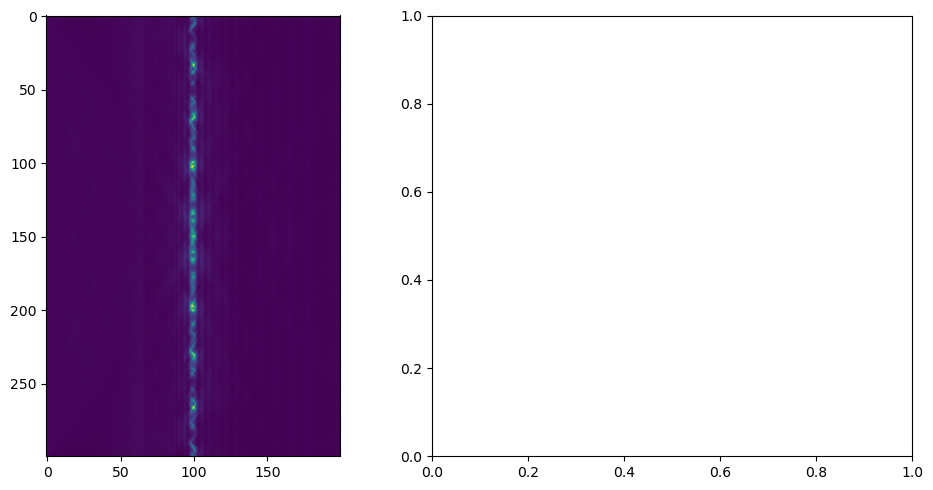

In [446]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
ax = ax.ravel()
ax[0].imshow(np.abs(mlvolume[M//2, :, :])**2)

plt.tight_layout() 

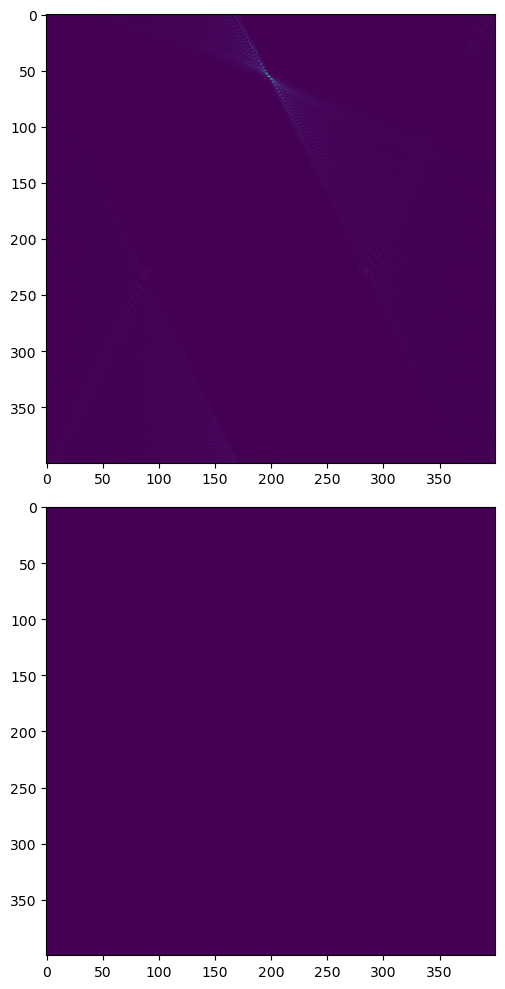

In [412]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(5, 10))
ax = ax.ravel()
ax[0].imshow(np.abs(lsvolume[M//2, :, :])**2)
ax[1].imshow(np.abs(mlvolume[M//2, :, :])**2)

plt.tight_layout() 

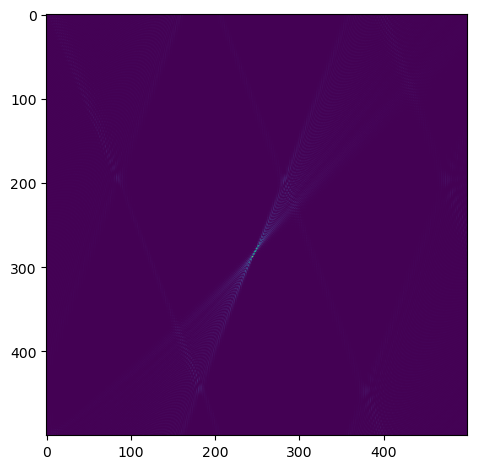

In [334]:
plt.imshow(np.abs(lsvolume[M//2, :, :])**2)
plt.tight_layout() 

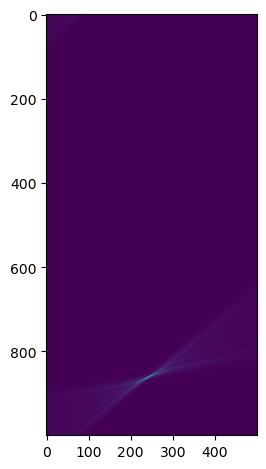

In [212]:
plt.imshow(np.abs(volume[M//2, :, :])**2)
plt.tight_layout() 

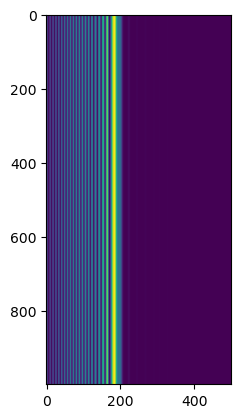

In [213]:
plt.imshow(np.abs(volume[:, 900, :])**2)

In [ ]:
w = 0.011 # source half width (m)
L1 = 0.5    # side length (m)
M = 250     # No. of samples
dx1 = L1/M  # source sample interval

x1 = np.linspace(-L1/2, L1/2-dx1, M, endpoint=True) # source coordinates
y1 = x1
X1, Y1 = np.meshgrid(x1, y1)

u1 = rect(X1/(2*w)) * rect(Y1/(2*w))    # source field
wavelength = 500e-9 # wavelength (m)
z = 2000        # propagation distance (m)

u2, L2 = FraunhoferProp(u1, L1, wavelength, z)
dx2 = L2/M
x2 = np.linspace(-L2/2, L2/2 - dx2, num=M, endpoint=True)
y2 = x2
wz = wavelength*z

I2 = np.abs(u2**2)
I2a = (4*w**2)**2/wz**2 * np.sinc(2*w*x2/wz)**2 * np.sinc(2*w*y2/wz)**2

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
ax = axes.ravel()

Nf = w**2 / (wavelength*z)

ax[0].imshow(np.power(I2, 1/3), extent=(-L2/2, L2/2, -L2/2, L2/2))
# ax[0].axis('equal')
ax[0].set_xlabel('m')
ax[0].set_xticks(np.arange(-L2/2, L2/2+dx2, dx2*50))
ax[0].set_yticks(np.arange(-L2/2, L2/2+dx2, dx2*50))
# # ax.set_xticklabels(x_label_list)
ax[0].set_ylabel('m')
ax[0].set_xlabel('m')
ax[0].set_title(f'z = {z} m')

ax[1].plot(x2, I2[int(M/2-1), :], 'ro', markersize=0.5)
ax[1].plot(x2, I2a, 'b-', markersize=0.5)
ax[1].set_ylabel('Irradiance')
ax[1].set_xlabel('m')
ax[1].set_title(f'z = {z} m')
plt.show()